In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import sys
sys.path.insert(0, '..')

from mcmc_polymer.polymer import PolymerChain
from mcmc_polymer.rosenbluth import RosenbluthMCMC

## Cubic-Lattice Rosenbluth (R&R 1955 exact setup)

`LatticeRosenbluthMCMC` grows chains on a **simple cubic lattice** — discrete ±x/±y/±z steps, self-avoiding constraint enforced against visited sites, Rosenbluth weight = ∏ (free_neighbors / 6).  This matches the original 1955 paper and should agree closely with its published R_ee values.

In [2]:
import importlib
import numpy as np
import sys
sys.path.insert(0, '..')

import mcmc_polymer.lattice_rosenbluth as _lr_mod
importlib.reload(_lr_mod)
from mcmc_polymer.lattice_rosenbluth import LatticeRosenbluthMCMC

# CHAIN_LENGTHS = bond count N (paper convention).
# The sampler needs n_monomers = N + 1 because the loop runs n_monomers-1 times.
CHAIN_LENGTHS = [8, 16, 32, 64]
N_CHAINS = 10000
start_position = np.array([0.0, 0.0, 0.0])

# Rosenbluth & Rosenbluth (1955) Table I, simple cubic lattice
# Key: N = number of bonds  |  Value: <R²> weighted Rosenbluth average
RR1955_R2 = {
    8:  12.81,
    16: 29.80,
    32: 68.35,
    64: 162.40,
}

lattice_results = {}

for N in CHAIN_LENGTHS:
    print(f"Growing {N_CHAINS} chains, N={N} bonds ({N+1} monomers) ...")
    sampler = LatticeRosenbluthMCMC(n_monomers=N + 1)
    chains, weights = sampler.sample(N_CHAINS, start=start_position)
    weights = np.array(weights)
    r_sq    = np.array([np.sum((c[-1] - c[0]) ** 2) for c in chains])

    n_dead    = int(np.sum(weights == 0))
    w_sum     = weights.sum()
    w_r2_mean = np.sum(weights * r_sq) / w_sum
    w_r2_std  = np.sqrt(np.sum(weights * (r_sq - w_r2_mean) ** 2) / w_sum)

    lattice_results[N] = {
        'n_dead':    n_dead,
        'w_r2_mean': w_r2_mean,
        'w_r2_std':  w_r2_std,
        'published': RR1955_R2[N],
    }

print()
print("Cubic-Lattice Rosenbluth  ⟨R²⟩  vs. Rosenbluth & Rosenbluth (1955) Table I")
print("=" * 78)
print(f"{'N':>5}  {'Dead':>6}  {'⟨R²⟩ (weighted)':>22}  {'distrib. std':>13}  {'R&R 1955':>10}  {'Δ%':>7}")
print("-" * 78)
for n in CHAIN_LENGTHS:
    r = lattice_results[n]
    diff = 100 * (r['w_r2_mean'] - r['published']) / r['published']
    print(f"{n:>5}  {r['n_dead']:>6}  "
          f"{r['w_r2_mean']:>8.2f} ± {r['w_r2_std']:<6.2f}  "
          f"{r['w_r2_std']:>13.2f}  "
          f"{r['published']:>10.2f}  {diff:>+6.1f}%")
print("=" * 78)
print("N = bonds (paper convention). Dead = dead-end chains (w=0, r²=0).")


Growing 10000 chains, N=8 bonds (9 monomers) ...
Growing 10000 chains, N=16 bonds (17 monomers) ...
Growing 10000 chains, N=32 bonds (33 monomers) ...
Growing 10000 chains, N=64 bonds (65 monomers) ...

Cubic-Lattice Rosenbluth  ⟨R²⟩  vs. Rosenbluth & Rosenbluth (1955) Table I
    N    Dead         ⟨R²⟩ (weighted)   distrib. std    R&R 1955       Δ%
------------------------------------------------------------------------------
    8       0     12.76 ± 7.51             7.51       12.81    -0.4%
   16       0     29.32 ± 18.68           18.68       29.80    -1.6%
   32       7     68.39 ± 45.27           45.27       68.35    +0.1%
   64      35    156.27 ± 107.59         107.59      162.40    -3.8%
N = bonds (paper convention). Dead = dead-end chains (w=0, r²=0).


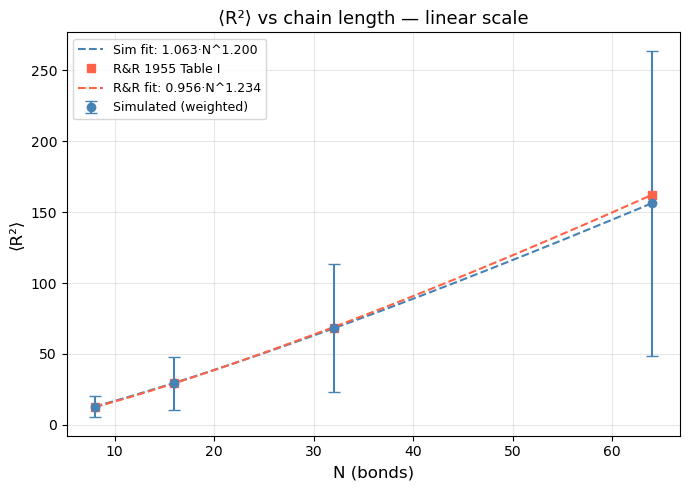


Simulated fit :  ⟨R²⟩ = 1.063 · N^1.200
R&R 1955 fit  :  ⟨R²⟩ = 0.956 · N^1.234
Expected exponent for 3D SAW: 2ν ≈ 1.176  (ν = 0.588)


In [6]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

N_arr      = np.array(CHAIN_LENGTHS, dtype=float)
sim_mean   = np.array([lattice_results[n]['w_r2_mean'] for n in CHAIN_LENGTHS])
sim_std    = np.array([lattice_results[n]['w_r2_std']  for n in CHAIN_LENGTHS])
pub_values = np.array([lattice_results[n]['published'] for n in CHAIN_LENGTHS])

def power_law(n, a, nu):
    return a * n ** nu

popt_sim, _ = curve_fit(power_law, N_arr, sim_mean, p0=[1.0, 1.2])
popt_pub, _ = curve_fit(power_law, N_arr, pub_values, p0=[1.0, 1.2])

N_fit = np.linspace(N_arr[0], N_arr[-1], 300)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(N_arr, sim_mean, yerr=sim_std, fmt='o', capsize=4,
            label='Simulated (weighted)', color='steelblue', zorder=5)
ax.plot(N_fit, power_law(N_fit, *popt_sim), '--', color='steelblue',
        label=f'Sim fit: {popt_sim[0]:.3f}·N^{popt_sim[1]:.3f}')
ax.plot(N_arr, pub_values, 's', color='tomato', zorder=5,
        label='R&R 1955 Table I')
ax.plot(N_fit, power_law(N_fit, *popt_pub), '--', color='tomato',
        label=f'R&R fit: {popt_pub[0]:.3f}·N^{popt_pub[1]:.3f}')
ax.set_xlabel('N (bonds)', fontsize=12)
ax.set_ylabel('⟨R²⟩', fontsize=12)
ax.set_title('⟨R²⟩ vs chain length — linear scale', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lattice_rosenbluth_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSimulated fit :  ⟨R²⟩ = {popt_sim[0]:.3f} · N^{popt_sim[1]:.3f}")
print(f"R&R 1955 fit  :  ⟨R²⟩ = {popt_pub[0]:.3f} · N^{popt_pub[1]:.3f}")
print(f"Expected exponent for 3D SAW: 2ν ≈ 1.176  (ν = 0.588)")
